# l-DEP

This notebook shows a minimal, reproducible example for some of the features of the l-DEP implementation.  
Two l-DEP estimators will be created, one for each available solver.
They will both be trained on a toy binary dataset (scikit-learn's "two moons" with noise) and their decision boundary will be displayed with matplotlib.

The definition and activation function of the l-DEP, as well as the training method, were implemented based on the works in *Oliveira, Angelica Lourenço, and Marcos Eduardo Valle. "Linear dilation-erosion perceptron trained using a convex-concave procedure." International Conference on Soft Computing and Pattern Recognition. Cham: Springer International Publishing, 2020*.

## 1. Train the l-DEP estimators

First, let us import the needed modules.

For readability purposes, only the bare minimum is included here, the modules used for display can be found at the start of the second section.

In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from sklearn_morpho.classifiers.ldep import LDEP

We then create a dataset, optionally generated with a set seed for reproducibility.

Here, the points' labels are transformed from $\{0, 1\}$ to $\{red, blue\}$ to show how the estimator supports it.  
This will also be useful later, when displaying the results, but it is obviously not mandatory.

In [2]:
random_state = np.random.RandomState(42)

X, y = make_moons(n_samples=1000, noise=0.2, random_state=random_state)
y = np.array(['red', 'blue'])[y]

A perceptron can then be created, then trained on this dataset.  
Here, the parameters are all left to the default values, except for:

- `random_state` for reproducibility once again
- `verbose` to display useful information

The other parameters are described in `help(LDEP)` and will not be covered here (except for `use_dccp_library`, see below).

Finally, the dataset is split in two parts using `train_test_split`: one for training and another for testing, to avoid bias.

In [3]:
ldep = LDEP(verbose=1, random_state=random_state)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state
)

ldep.fit(X_train, y_train)

Starting fitting with DCCP (with manual linearization)
Epoch 1, training cost: 80.64931281, validation: 11.02109101
Epoch 2, training cost: 26.35589429, validation: 8.90501340
Epoch 3, training cost: 23.41365715, validation: 11.34998424
Epoch 4, training cost: 21.20152995, validation: 20.52147893
Epoch 5, training cost: 19.73029386, validation: 38.28783038
Epoch 6, training cost: 18.73111374, validation: 39.65899571
Epoch 7, training cost: 18.73111276, validation: 38.61373117
DCCP done in 7 epochs, final validation cost is 38.61373117 in 0.56s


,verbose,1
,random_state,RandomState(M...0x7FAB299D7340
,latent_dims,"(10, ...)"
,margin,1.0
,penalty,0.0
,validation_ratio,0.3
,weighting_method,None
,stopping_methods,None
,solver,None
Name,Type,Value
classes_,"ndarray[<U4](2,)","['blue','red']"


Notice how two solving methods are available: the default one uses manual linearization of DC constraints and multiple epochs, while the other uses the `'dccp'` solver from the `dccp` library.

Empirical results show that, while the dccp solver is slower, it generally gives better results, so the choice of either one or the other solver depends on the resources of the end user.
Another detail is that, by its nature of having some of the logic implemented inside sklearn-morpho's source code and not completely through another library's solver, the manual linearization method might be more customizable, as it allows for the use of the modular stopping and inversion methods.

To choose the solver, specify value to the `solver` parameter when instantiating an estimator.
`"dccp"` will use the DCCP solver and logic, while other values will be passed directly to cvxpy through the manual linearization method.

In [5]:
ldep_dccp = LDEP(solver='dccp', verbose=1, random_state=random_state)
ldep_dccp.fit(X_train, y_train)

Starting fitting with DCCP (with dccp library)
DCCP done, training_cost cost is 55.60404833 in 6.68s


,solver,'dccp'
,verbose,1
,random_state,RandomState(M...0x7FAB299D7340
,latent_dims,"(10, ...)"
,margin,1.0
,penalty,0.0
,validation_ratio,0.3
,weighting_method,None
,stopping_methods,None
Name,Type,Value
classes_,"ndarray[<U4](2,)","['blue','red']"


The estimators are now trained, it is now possible to display the results of the training.

## 2. Display the results

Let us once again import useful modules to display the results and calculate the F1 score.

Scikit-learn implements the `DecisionBoundaryDisplay` function, which will be used here to display the decision boundary.

In [6]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import f1_score

We can now calculate the F1 score:

Since the labels are not numbered here (they are color names), a `pos_label` is explicitly defined.

In [7]:
score_test = f1_score(y_test, ldep.predict(X_test), pos_label=np.unique(y)[1])
score_test_dccp = f1_score(
    y_test, ldep_dccp.predict(X_test), pos_label=np.unique(y)[1]
)

Now for the results:

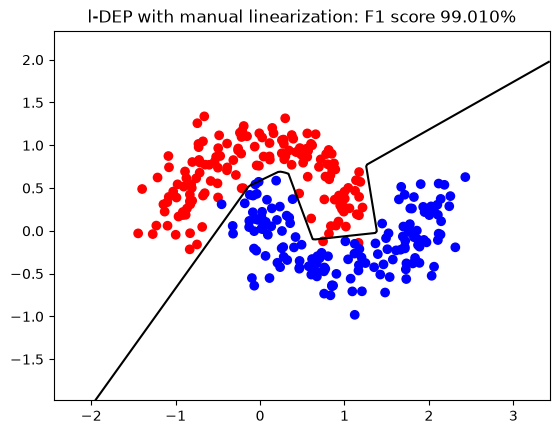

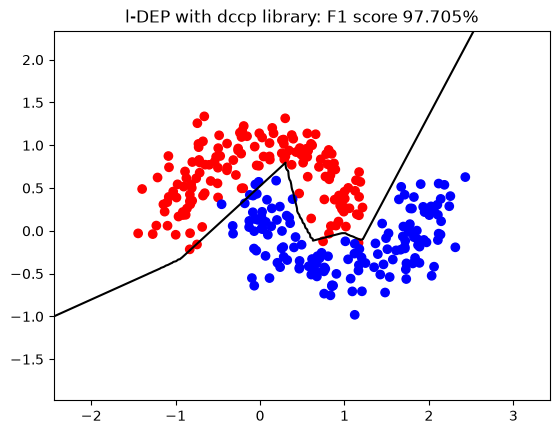

In [8]:
for name, estimator, score in (
    ('l-DEP with manual linearization', ldep, score_test),
    ('l-DEP with dccp library', ldep_dccp, score_test_dccp),
):
    # draw the decision boundary
    disp = DecisionBoundaryDisplay.from_estimator(
        estimator,
        X_test,
        response_method='decision_function',
        grid_resolution=200,
        plot_method='contour',
        levels=[0],
        colors='black',
    )

    # add the points
    ax = disp.ax_
    ax.scatter(*X_test.T, color=y_test)
    ax.title.set_text(f'{name}: F1 score {score * 100:.3f}%')
    plt.show()